<a href="https://colab.research.google.com/github/cuzmyk/machine_learning/blob/main/2s_5pr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Задание 1. Использование предобученной модели

### 1.1. Выберите и импортируйте предобученную модель СНС для решения задач классификации из имеющихся в Keras: https://keras.io/api/applications/

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from google.colab.patches import cv2_imshow
from tensorflow import keras
from google.colab import files
from io import BytesIO
from PIL import Image
from urllib.request import urlopen

# импорт модели NasNetLarge
model = keras.applications.NASNetLarge(
    input_shape=None,
    include_top=True,
    weights="imagenet",
    input_tensor=None,
    pooling=None,
    classifier_activation="softmax",
)
# Вывод краткого описания архитектуры созданной модели
model.summary()

359748576/359748576 ━━━━━━━━━━━━━━━━━━━━ 17s 0us/step


Model: "nasnet_large"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 331, 331, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv1 (Conv2D)       │ (None, 165, 165, 96)   │          2,592 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_bn1                  │ (None, 165, 165, 96)   │            384 │ stem_conv1[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation (Activation)   │ (None, 165, 165, 96)   │              0 │ stem_bn1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reduction_conv_1_stem_1   │ (None, 165, 165, 42)   │          4,032 │ activation[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reduction_bn_1_stem_1     │ (None, 165, 165, 42)   │            168 │ reduction_conv_1_stem… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_1 (Activation) │ (None, 165, 165, 42)   │              0 │ reduction_bn_1_stem_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_3 (Activation) │ (None, 165, 165, 96)   │              0 │ stem_bn1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv_1_pad_red… │ (None, 169, 169, 42)   │              0 │ activation_1[0][0]     │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv_1_pad_red… │ (None, 171, 171, 96)   │              0 │ activation_3[0][0]     │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv_1_reducti… │ (None, 83, 83, 42)     │          2,814 │ separable_conv_1_pad_… │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv_1_reducti… │ (None, 83, 83, 42)     │          8,736 │ separable_conv_1_pad_… │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv_1_bn_redu… │ (None, 83, 83, 42)     │            168 │ separable_conv_1_redu… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv_1_bn_redu… │ (None, 83, 83, 42)     │            168 │ separable_conv_1_redu… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_2 (Activation) │ (None, 83, 83, 42)     │              0 │ separable_conv_1_bn_r… │
├──────────────────────

 Total params: 88,949,818 (339.32 MB)

 Trainable params: 88,753,150 (338.57 MB)

 Non-trainable params: 196,668 (768.23 KB)

### 1.2. Загрузите из сети Интернет 5 изображений с разными классами, из тех, что приведены в [списке](https://gist.github.com/yrevar/942d3a0ac09ec9e5eb3a), и сохраните их представление в список images

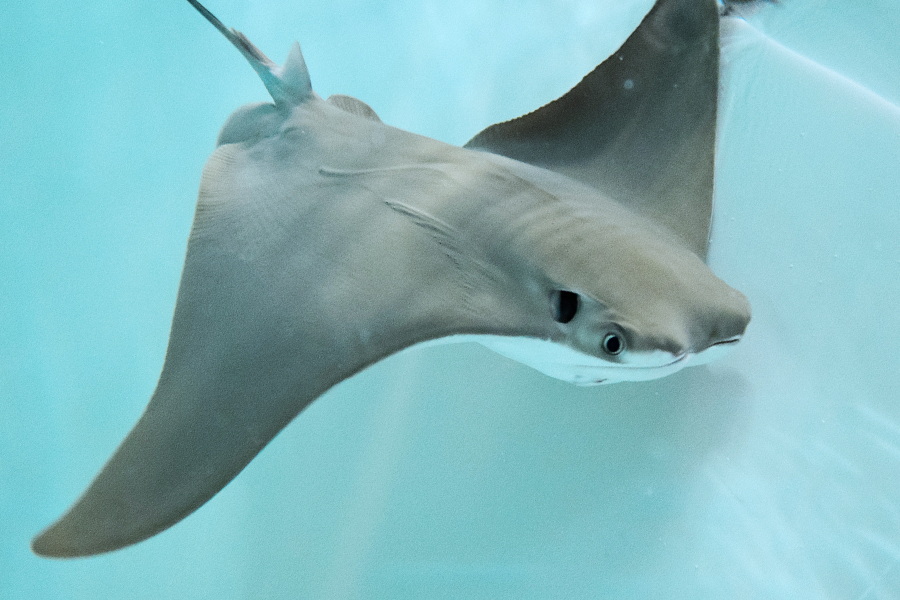

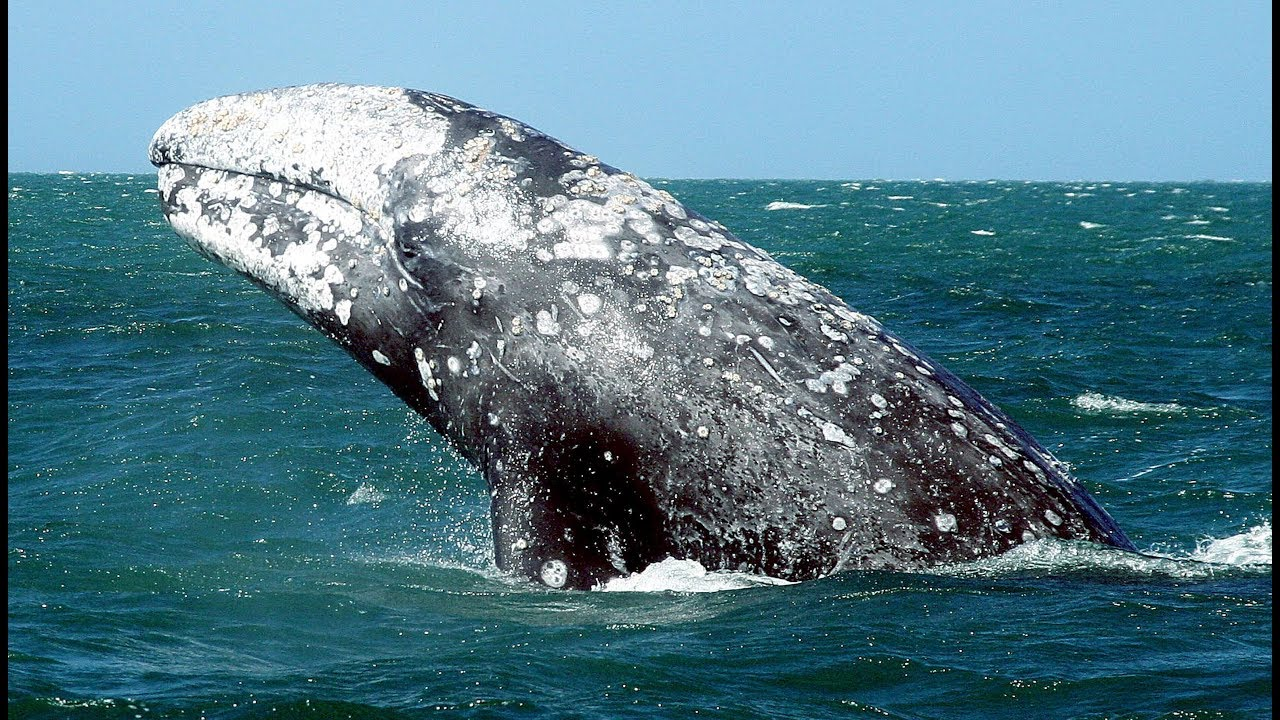

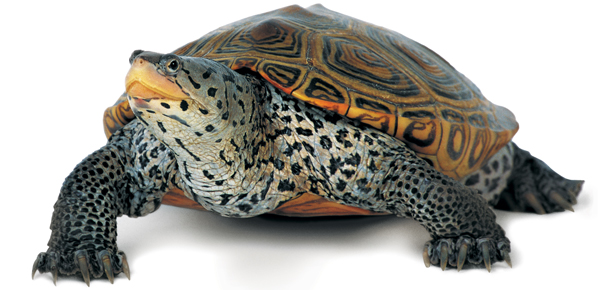

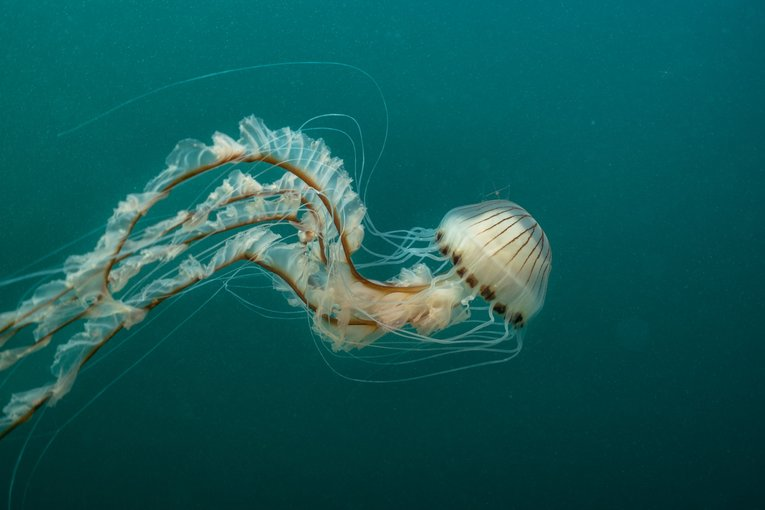

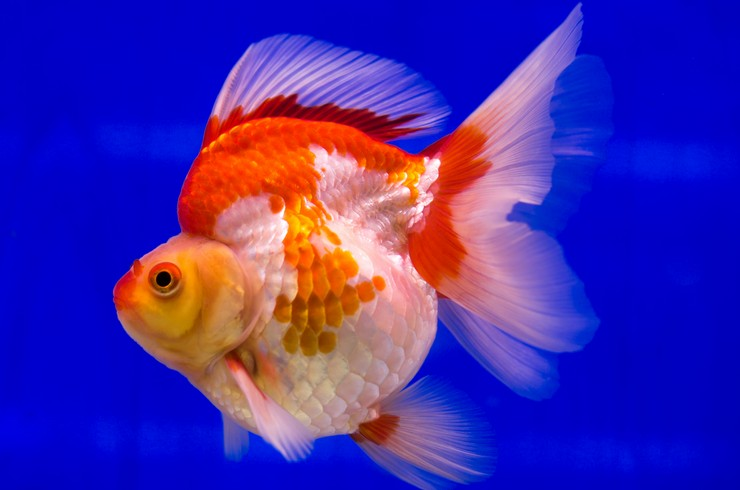

In [ ]:
from google.colab.patches import cv2_imshow
#from urllib.request import urlopen
# картинки и ссылки
# используя метод urlopen, получаем объект запроса по ссылке (изображение)
# и сохраняем его в виде потокового набора данных в переменную "req"
# 1-скат, 2-серый кит, 3-черепаха, 4-медуза, 5-золотая рыбка
req_1 = urlopen('https://www.moskvarium.ru/upload/iblock/fff/900kh600.jpg')
req_2 = urlopen('https://i.ytimg.com/vi/THB78mk9lBU/maxresdefault.jpg')
req_3 = urlopen('https://www.mdsg.umd.edu/sites/default/files/images/terrapin_no_backgroud.jpg')
req_4 = urlopen('https://s3.eu-west-1.amazonaws.com/media.mcsuk.org/images/RS31885_image-131-lpr.width-765.jpg')
req_5 = urlopen('https://blog.tetra.net/ru/ru/wp-content/uploads/2021/02/riukin-korotkotelaya-poroda-zolotyh-rybok.jpg')

reqs = [req_1, req_2,req_3, req_4, req_5]
images = []
for req in reqs:                                                                                      # и сохраняем его в виде потокового набора данных в переменную "req"
  image = np.asarray(bytearray(req.read()), dtype=np.uint8) # преобразуем потоковый набор данных в массив numpy
  image = cv2.imdecode(image, -1)
  images.append(image) # декодируем изображение в привычный для отображения формат
  cv2_imshow(image) # Выводим изображение, используя метод cv2_imshow()


### 1.3. Напишите функцию, принимающую на вход список с исходными изображениями и возвращающую список с преобразованными изображениями под формат входных данных выбранной Вами модели СНС (нормализация).

(Не забудьте создать независимую копию исходного списка в теле функции, для обработки именно независимой копии, а не оригинального списка)

In [ ]:
from keras.applications.nasnet import preprocess_input
def normalize(images, shape = (331, 331)):
# Создание независимой копии исходного списка изображений
    proc_images = images.copy()
    # Преобразование каждого изображения
    for i in range(len(proc_images)):
        proc_images[i] = cv2.resize(proc_images[i], shape)
        proc_images[i] = preprocess_input(np.array(proc_images[i]))

    return np.asarray(proc_images)

In [ ]:
processed_images = normalize(images)

In [ ]:
processed_images.shape

(5, 331, 331, 3)

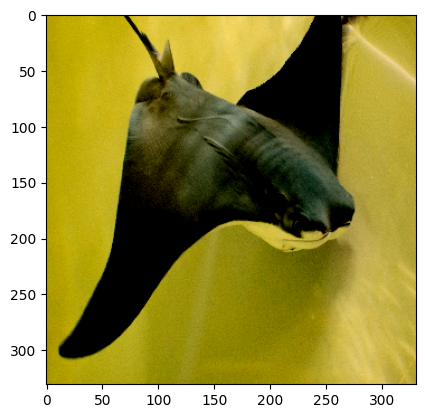

In [ ]:
from matplotlib import pyplot as plt

plt.imshow(processed_images[0])

### 1.5. Выведите изображения и соответствующие им классы (как в примере из теории)

In [ ]:
res = model.predict(processed_images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 22s 22s/step


In [ ]:
res

array([[1.56241163e-04, 1.12561080e-04, 6.76158816e-04, ...,
        1.09726716e-04, 8.72205128e-05, 1.37100986e-04],
       [7.04445920e-05, 3.59281439e-05, 3.15732439e-04, ...,
        1.60785057e-04, 7.66609592e-05, 4.34937501e-05],
       [1.25079183e-04, 1.64881392e-04, 3.32759191e-05, ...,
        9.97848838e-05, 2.75555740e-05, 4.98804802e-05],
       [7.06099672e-05, 1.41481243e-04, 8.50628494e-05, ...,
        1.21138284e-04, 1.56362497e-04, 1.02320555e-04],
       [4.66573227e-04, 8.97674739e-01, 5.56125742e-05, ...,
        4.23466918e-05, 6.90786255e-05, 8.95976846e-05]], dtype=float32)

In [ ]:
for i in range(len(processed_images)):

    # Предсказание класса объекта
    res = model.predict(processed_images[i].reshape(1, 331, 331, 3))

    # Вывод номера класса объекта
    print(np.argmax(res))
    print(keras.applications.nasnet.decode_predictions(res, top=3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step
6
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
[[('n01498041', 'stingray', np.float32(0.8093303)), ('n01496331', 'electric_ray', np.float32(0.057997372)), ('n01494475', 'hammerhead', np.float32(0.0017588113))]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
147
[[('n02066245', 'grey_whale', np.float32(0.9074521)), ('n03743016', 'megalith', np.float32(0.0008900132)), ('n01665541', 'leatherback_turtle', np.float32(0.0006458419))]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
36
[[('n01667778', 'terrapin', np.float32(0.9187715)), ('n01667114', 'mud_turtle', np.float32(0.0032919247)), ('n01665541', 'leatherback_turtle', np.float32(0.0015271178))]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
107
[[('n01910747', 'jellyfish', np.float32(0.9039899)), ('n01530575', 'brambling', np.float32(0.00055881456)), ('n01990800', 'isopod', np.float32(0.00037546686))]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1
[[('n01443537', 'goldfish', np.float32(0.89767474)), ('n02606052', 'rock_beauty',

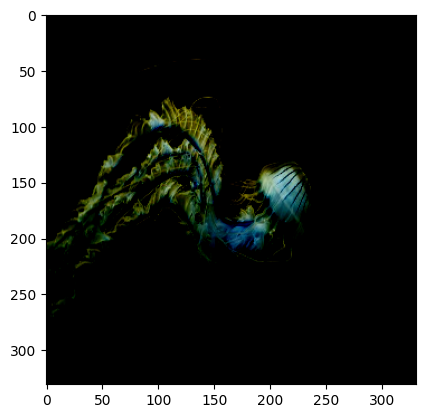

In [ ]:
    plt.imshow(processed_images[3])

# Задание 2. Использование обученной модели для работы со своим датасетом

### 2.1. Выберите и импортируйте предобученную модель СНС для решения задач классификации из имеющихся в Keras: https://keras.io/api/applications/

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from io import BytesIO
from PIL import Image
from urllib.request import urlopen
import os
from imutils import paths
import tensorflow as tf
import keras
from keras import layers
from keras.layers import Dense, Flatten
from keras.models import Sequential
from keras.optimizers import Adam
from keras.utils import image_dataset_from_directory
from keras.applications import NASNetMobile
import random
import pathlib
import cv2

### 2.2. Подготовка тренировочных данных. Разделение на обучающую и тестовую выборку

In [ ]:
import os
import random
import numpy as np
from imutils import paths
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras.applications import NASNetMobile
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.nasnet import preprocess_input

In [ ]:
! pip install wldhx.yadisk-direct
! curl -L $(yadisk-direct https://disk.yandex.ru/d/WA8k7NGVrqm7hQ) -o arch.zip
! unzip -qq arch.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:--  0:00:01 --:--:--     0
100 95.5M  100 95.5M    0     0  7738k      0  0:00:12  0:00:12 --:--:-- 12.8M


In [ ]:
base_dir = "/content/Vegetable Images"
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")
val_dir = os.path.join(base_dir, "validation")

# Параметры
IMG_SIZE = (224, 224)  # NASNetMobile требует 224x224
BATCH_SIZE = 32
SEED = 42

# Создаем генератор для загрузки изображений
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.0  # Мы сами разделим данные
)

# Загружаем тренировочные данные
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

# Загружаем тестовые данные (для финальной оценки)
test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Загружаем валидационные данные
val_generator = datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Получаем метки классов
class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)

Found 3000 images belonging to 3 classes.
Found 600 images belonging to 3 classes.
Found 600 images belonging to 3 classes.


### 2.3. Обучение своей модели на основе предобученной модели "*название модели, выбранной в п.2.1.*"

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.7619 - loss: 0.5626

93/93 ━━━━━━━━━━━━━━━━━━━━ 70s 389ms/step - accuracy: 0.7632 - loss: 0.5599 - val_accuracy: 0.9896 - val_loss: 0.0769
Epoch 2/20
 1/93 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - accuracy: 0.9688 - loss: 0.1174

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9688 - loss: 0.1174 - val_accuracy: 0.9913 - val_loss: 0.0759
Epoch 3/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.9874 - loss: 0.0707

93/93 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - accuracy: 0.9874 - loss: 0.0705 - val_accuracy: 0.9948 - val_loss: 0.0337
Epoch 4/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 1.0000 - loss: 0.0527 - val_accuracy: 0.9948 - val_loss: 0.0333
Epoch 5/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9921 - loss: 0.0379

93/93 ━━━━━━━━━━━━━━━━━━━━ 18s 97ms/step - accuracy: 0.9921 - loss: 0.0379 - val_accuracy: 0.9965 - val_loss: 0.0206
Epoch 6/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9375 - loss: 0.0674 - val_accuracy: 0.9965 - val_loss: 0.0205
Epoch 7/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 17s 77ms/step - accuracy: 0.9961 - loss: 0.0239 - val_accuracy: 0.9965 - val_loss: 0.0144
Epoch 8/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 1.0000 - loss: 0.0114 - val_accuracy: 0.9965 - val_loss: 0.0143
Epoch 9/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.9975 - loss: 0.0168 - val_accuracy: 0.9965 - val_loss: 0.0114
Epoch 10/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 1.0000 - loss: 0.0028 - val_accuracy: 0.9965 - val_loss: 0.0113
Epoch 11/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.9977 - loss: 0.0131

93/93 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - accuracy: 0.9977 - loss: 0.0131 - val_accuracy: 0.9983 - val_loss: 0.0093
Epoch 12/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 1.0000 - loss: 0.0032 - val_accuracy: 0.9983 - val_loss: 0.0093
Epoch 13/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 16s 78ms/step - accuracy: 0.9999 - loss: 0.0075 - val_accuracy: 0.9983 - val_loss: 0.0074
Epoch 14/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9688 - loss: 0.0620 - val_accuracy: 0.9983 - val_loss: 0.0073
Epoch 15/20
92/93 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9992 - loss: 0.0068

93/93 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - accuracy: 0.9991 - loss: 0.0068 - val_accuracy: 1.0000 - val_loss: 0.0059
Epoch 16/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 1.0000 - loss: 0.0072 - val_accuracy: 1.0000 - val_loss: 0.0059
Epoch 17/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - accuracy: 0.9998 - loss: 0.0057 - val_accuracy: 1.0000 - val_loss: 0.0052
Epoch 18/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 1.0000 - val_loss: 0.0052
Epoch 19/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.9995 - loss: 0.0045 - val_accuracy: 1.0000 - val_loss: 0.0054
Epoch 20/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 1.0000 - loss: 0.0044 - val_accuracy: 1.0000 - val_loss: 0.0053
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 434ms/step - accuracy: 0.9988 - loss: 0.0040
Test accuracy: 99.83%


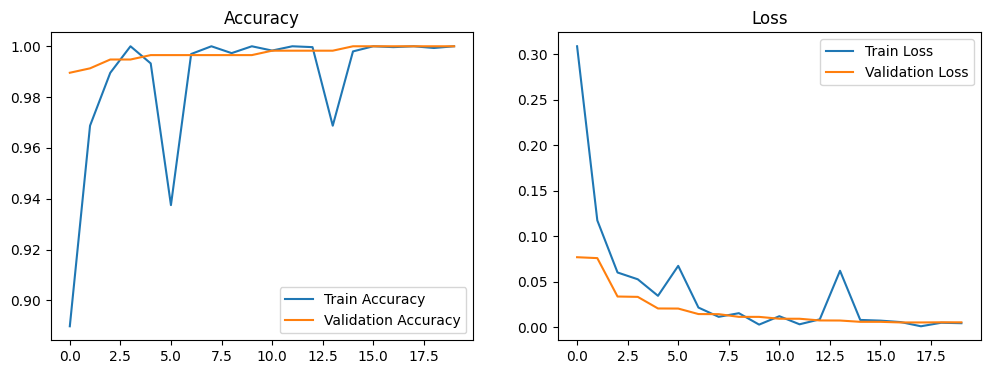

In [ ]:
from tensorflow.keras.applications import NASNetMobile
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Параметры модели
INIT_LR = 1e-4
EPOCHS = 20

# Загружаем предобученную модель NASNetMobile
base_model = NASNetMobile(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Замораживаем слои базовой модели
base_model.trainable = False

# Создаем новую верхушку модели
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(num_classes, activation='softmax')(x)

# Собираем полную модель
model = Model(inputs=base_model.input, outputs=predictions)

# Компилируем модель
model.compile(
    optimizer=Adam(learning_rate=INIT_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint("best_model.h5", monitor='val_accuracy', save_best_only=True)
]

# Обучение модели
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_data=val_generator,
    validation_steps=val_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

# Оценка на тестовых данных
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc*100:.2f}%")

### 2.4. Визуализация процесса обучения модели

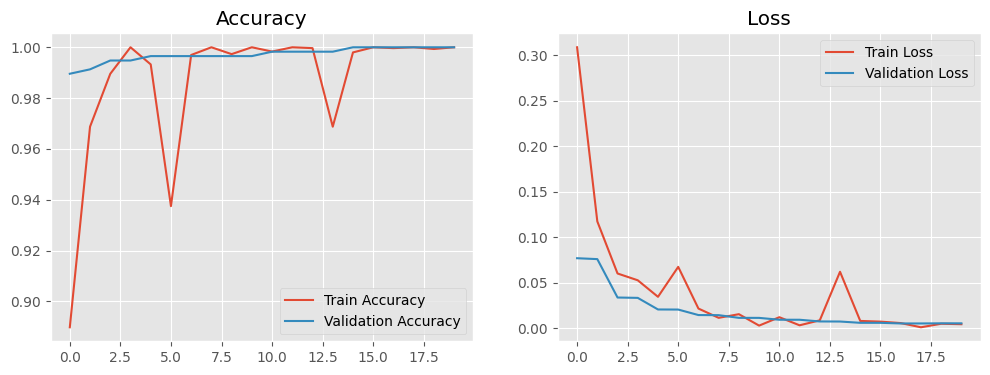

In [ ]:
# Визуализация обучения
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()
plt.show()

### 2.5. Подготовьте набор проверочных данных (examples)

In [ ]:
base_dir = "/content/Vegetable Images"
test_dir = os.path.join(base_dir, "test")

# 1. Собираем примеры из тестовой папки
def prepare_examples(test_dir, examples_per_class=5):
    examples = []
    example_labels = []
    example_paths = []

    for class_name in sorted(os.listdir(test_dir)):
        class_dir = os.path.join(test_dir, class_name)
        if not os.path.isdir(class_dir):
            continue

        # Берем первые N изображений из каждого класса
        images = sorted(os.listdir(class_dir))[:examples_per_class]

        for img_name in images:
            img_path = os.path.join(class_dir, img_name)

            # Загружаем и предобрабатываем изображение
            img = load_img(img_path, target_size=(224, 224))
            img_array = img_to_array(img)
            img_array = preprocess_input(img_array)

            examples.append(img_array)
            example_labels.append(class_name)
            example_paths.append(img_path)

    return np.array(examples), np.array(example_labels), example_paths

# Подготавливаем примеры (по 5 на класс)
X_examples, y_examples, example_paths = prepare_examples(test_dir)

### 2.6. Реализуйте графический интерфейс для взаимодействия с обученной моделью, используя [Gradio](https://www.gradio.app/guides/image-classification-in-tensorflow). В качестве примеров (параметр examples в Gradio), используйте изображения из списка images (п.1.2.)

In [ ]:
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.2/322.2 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 110.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 5.5 MB/s eta 0:00:00


In [ ]:
import gradio as gr
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.nasnet import preprocess_input
import os

model = load_model('best_model.h5')

class_names = ['Carrot', 'Cucumber', 'Radish']

In [ ]:
# 3. Функция для предсказания
def predict_vegetable(image):
    """
    Обрабатывает загруженное изображение и возвращает предсказание модели
    """
    # Преобразование изображения в массив и предобработка
    img = image.resize((224, 224))  # NASNetMobile требует 224x224
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)  # Добавляем размерность батча

    # Получаем предсказание
    preds = model.predict(img_array)[0]

    # Формируем результат в виде словаря
    result = {class_names[i]: float(preds[i]) for i in range(len(class_names))}

    # Возвращаем словарь с вероятностями и номером класса
    return result

In [ ]:
demo = gr.Interface(
    fn=predict_vegetable,
    inputs=gr.Image(type="pil", label="Загрузите изображение овоща"),
    outputs=gr.Label(num_top_classes=3, label="Результаты классификации"),
    examples=[
        "/content/Vegetable Images/train/Carrot/0001.jpg",
        "/content/Vegetable Images/train/Cucumber/0001.jpg",
        "/content/Vegetable Images/train/Radish/0003.jpg"
    ],
    title="Классификатор овощей",
    description="Загрузите изображение моркови, огурца или редиса, и модель определит, что это за овощ.",
    allow_flagging="never"
)

/usr/local/lib/python3.11/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated.Use `flagging_mode` instead.
  warnings.warn(


In [ ]:
demo.launch(debug=True, share=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://6b1a3ea15db54b2065.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://6b1a3ea15db54b2065.gradio.live


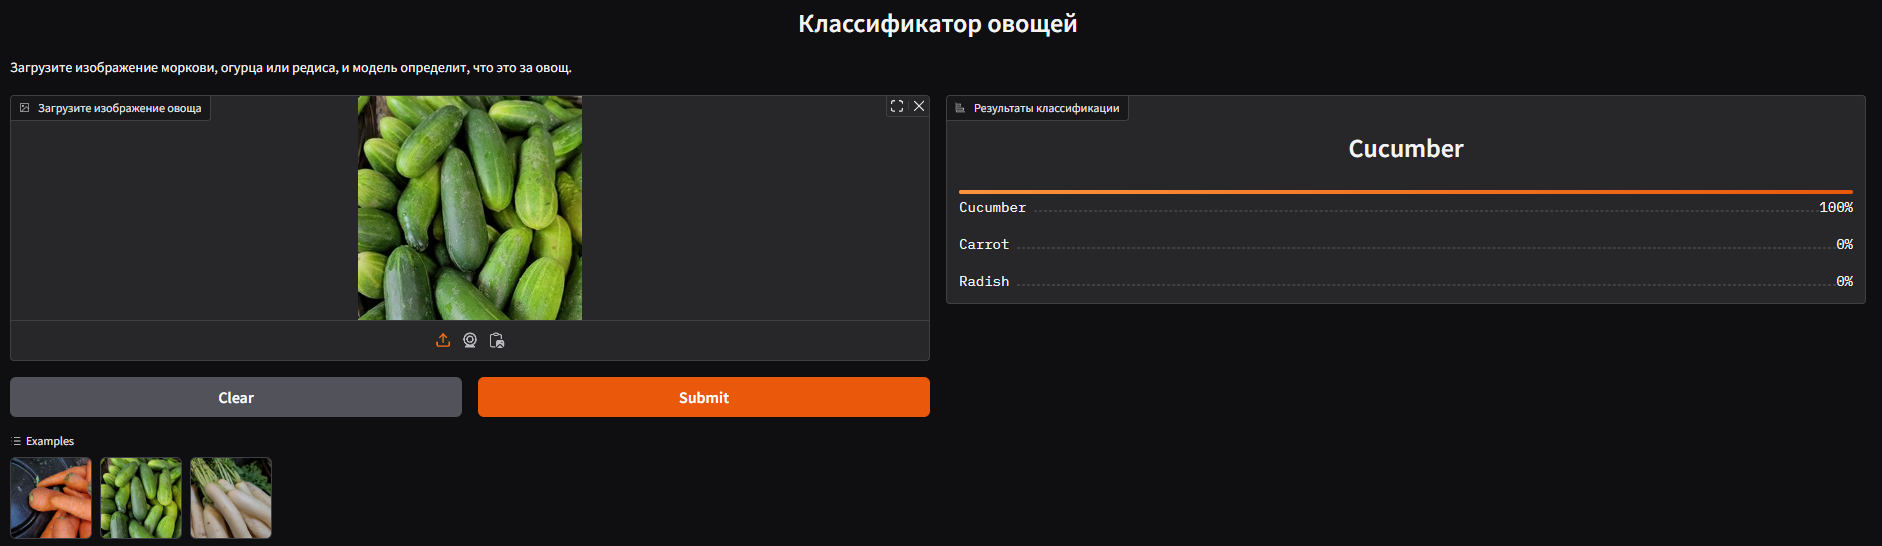

# Задание 3. Классификация набора пространственных данных EuroSat (для магистров)

- Ссылка на датасет: https://github.com/phelber/eurosat

- Описание на kaggle: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset

[Текст ссылки](https://)В этом задании Вам будет предоставлен набор данных EuroSat, который содержит снимки земной поверхности, снятые спутником Sentinel-2. Вам нужно будет обучить модель для классификации этих изображений на 10 классов, представляющих различные типы земного покрова.

### **3.1. Загрузка данных:**
  * [Скачайте](https://madm.dfki.de/files/sentinel/EuroSAT.zip) набор данных EuroSat
  * Разделите данные на обучающую, валидационную и тестовую выборки.



In [ ]:
! pip install wldhx.yadisk-direct
! curl -L $(yadisk-direct https://disk.yandex.ru/d/jAfboAPE2ftdQA) -o arch.zip
! unzip -qq arch.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:--  0:00:01 --:--:--     0
100 89.9M  100 89.9M    0     0  6153k      0  0:00:14  0:00:14 --:--:-- 8780k


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd

dataset_path = '/content/2750'

class_names = sorted(os.listdir(dataset_path))
print("Найдены классы:", class_names)

print("\nКоличество изображений в каждом классе:")
for class_name in class_names:
    class_dir = os.path.join(dataset_path, class_name)
    print(f"{class_name}: {len(os.listdir(class_dir))} изображений")

def create_image_dataframe(root_dir):
    image_paths = []
    labels = []

    for class_name in class_names:
        class_dir = os.path.join(root_dir, class_name)
        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            image_paths.append(img_path)
            labels.append(class_name)

    return pd.DataFrame({
        'filename': image_paths,
        'class': labels
    })

full_df = create_image_dataframe(dataset_path)

train_df, test_df = train_test_split(
    full_df,
    test_size=0.15,
    stratify=full_df['class'],
    random_state=42
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.1765,
    stratify=train_df['class'],
    random_state=42
)

print("\nРазмеры выборок:")
print(f"Обучающая: {len(train_df)} изображений")
print(f"Валидационная: {len(val_df)} изображений")
print(f"Тестовая: {len(test_df)} изображений")

Найдены классы: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']

Количество изображений в каждом классе:
AnnualCrop: 3000 изображений
Forest: 3000 изображений
HerbaceousVegetation: 3000 изображений
Highway: 2500 изображений
Industrial: 2500 изображений
Pasture: 2000 изображений
PermanentCrop: 2500 изображений
Residential: 3000 изображений
River: 2500 изображений
SeaLake: 3000 изображений

Размеры выборок:
Обучающая: 18899 изображений
Валидационная: 4051 изображений
Тестовая: 4050 изображений


### **3.2. Выбор архитектуры нейронной сети:**
  * Выберите архитектуру нейронной сети, основанную на трансферном обучении, например, ResNet50, VGG16 или InceptionV3 ([полный список](https://keras.io/api/applications/)).
  * Загрузите предобученную модель выбранной архитектуры.


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

# Параметры модели
INPUT_SHAPE = (224, 224, 3)
NUM_CLASSES = len(class_names)
BATCH_SIZE = 32

# Создаем генераторы данных с правильным размером
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filename',
    y_col='class',
    target_size=(224, 224),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filename',
    y_col='class',
    target_size=(224, 224),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=INPUT_SHAPE
)

# Добавление слоев классификации
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Замораживаем базовые слои
base_model.trainable = False

# Компиляция модели
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Found 18899 validated image filenames belonging to 10 classes.
Found 4051 validated image filenames belonging to 10 classes.


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 230, 230, 3)    │              0 │ input_layer_5[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 56, 56, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 56, 56, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 56, 56, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)             

 Total params: 25,696,138 (98.02 MB)

 Trainable params: 2,108,426 (8.04 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

### **3.3. Дообучение модели:**
  * Добавьте к предобученной модели несколько слоев для классификации изображений EuroSat.
  * Обучите модель на обучающей выборке.

In [ ]:
# 7. Обучение модели
history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    validation_data=val_generator,
    validation_steps=len(val_generator),
    epochs=30,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)
    ],
    verbose=1
)

# 8. Сохранение модели
model.save('eurosat_resnet50.h5')

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.1407 - loss: 2.3867

591/591 ━━━━━━━━━━━━━━━━━━━━ 286s 458ms/step - accuracy: 0.1407 - loss: 2.3865 - val_accuracy: 0.2510 - val_loss: 2.0964
Epoch 2/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.2202 - loss: 2.0970

591/591 ━━━━━━━━━━━━━━━━━━━━ 281s 399ms/step - accuracy: 0.2202 - loss: 2.0969 - val_accuracy: 0.3177 - val_loss: 1.9934
Epoch 3/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 262s 399ms/step - accuracy: 0.2447 - loss: 1.9951 - val_accuracy: 0.2565 - val_loss: 1.9300
Epoch 4/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 238s 403ms/step - accuracy: 0.2591 - loss: 1.9407 - val_accuracy: 0.2807 - val_loss: 1.8918
Epoch 5/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.2727 - loss: 1.9005

591/591 ━━━━━━━━━━━━━━━━━━━━ 262s 402ms/step - accuracy: 0.2727 - loss: 1.9005 - val_accuracy: 0.3621 - val_loss: 1.8427
Epoch 6/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 235s 397ms/step - accuracy: 0.2914 - loss: 1.8684 - val_accuracy: 0.3271 - val_loss: 1.8168
Epoch 7/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 242s 410ms/step - accuracy: 0.2934 - loss: 1.8440 - val_accuracy: 0.3379 - val_loss: 1.7855
Epoch 8/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 243s 411ms/step - accuracy: 0.3047 - loss: 1.8023 - val_accuracy: 0.3478 - val_loss: 1.7450
Epoch 9/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 251s 425ms/step - accuracy: 0.3108 - loss: 1.7854 - val_accuracy: 0.3362 - val_loss: 1.7177
Epoch 10/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 248s 419ms/step - accuracy: 0.3163 - loss: 1.7602 - val_accuracy: 0.3488 - val_loss: 1.7012
Epoch 11/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.3270 - loss: 1.7366

...

591/591 ━━━━━━━━━━━━━━━━━━━━ 238s 402ms/step - accuracy: 0.3878 - loss: 1.5964 - val_accuracy: 0.4426 - val_loss: 1.5400
Epoch 20/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 240s 406ms/step - accuracy: 0.3910 - loss: 1.5966 - val_accuracy: 0.4189 - val_loss: 1.5082
Epoch 21/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.3928 - loss: 1.5769

591/591 ━━━━━━━━━━━━━━━━━━━━ 243s 411ms/step - accuracy: 0.3928 - loss: 1.5769 - val_accuracy: 0.4441 - val_loss: 1.5072
Epoch 22/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.4115 - loss: 1.5608

591/591 ━━━━━━━━━━━━━━━━━━━━ 257s 402ms/step - accuracy: 0.4115 - loss: 1.5608 - val_accuracy: 0.4540 - val_loss: 1.4948
Epoch 23/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.4198 - loss: 1.5429

591/591 ━━━━━━━━━━━━━━━━━━━━ 245s 415ms/step - accuracy: 0.4198 - loss: 1.5429 - val_accuracy: 0.5253 - val_loss: 1.4827
Epoch 24/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 263s 417ms/step - accuracy: 0.4245 - loss: 1.5351 - val_accuracy: 0.5068 - val_loss: 1.4532
Epoch 25/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 268s 427ms/step - accuracy: 0.4295 - loss: 1.5196 - val_accuracy: 0.5241 - val_loss: 1.4644
Epoch 26/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 243s 411ms/step - accuracy: 0.4359 - loss: 1.5204 - val_accuracy: 0.4964 - val_loss: 1.4475
Epoch 27/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 240s 406ms/step - accuracy: 0.4423 - loss: 1.4946 - val_accuracy: 0.4651 - val_loss: 1.4327
Epoch 28/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.4471 - loss: 1.4959

591/591 ━━━━━━━━━━━━━━━━━━━━ 237s 402ms/step - accuracy: 0.4470 - loss: 1.4959 - val_accuracy: 0.5278 - val_loss: 1.4063
Epoch 29/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 239s 404ms/step - accuracy: 0.4490 - loss: 1.4844 - val_accuracy: 0.4779 - val_loss: 1.4045
Epoch 30/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 236s 399ms/step - accuracy: 0.4473 - loss: 1.4814 - val_accuracy: 0.5270 - val_loss: 1.4391




### **3.4. Оценка модели:**
  * Оцените производительность модели на валидационной и тестовой выборках.
  * Сравните результаты с другими архитектурами нейронных сетей.



Found 4050 validated image filenames belonging to 10 classes.
Оценка на валидационной выборке:
127/127 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step - accuracy: 0.4755 - loss: 1.3996
Validation Accuracy: 47.79%
Validation Loss: 1.4045

Оценка на тестовой выборке:


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


127/127 ━━━━━━━━━━━━━━━━━━━━ 13s 105ms/step - accuracy: 0.4803 - loss: 1.4221
Test Accuracy: 47.68%
Test Loss: 1.4132

Детальная оценка валидационной выборки:
127/127 ━━━━━━━━━━━━━━━━━━━━ 18s 114ms/step

Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop       0.55      0.71      0.62       450
              Forest       0.40      0.44      0.42       450
HerbaceousVegetation       0.23      0.35      0.28       451
             Highway       0.40      0.03      0.06       375
          Industrial       0.86      0.73      0.79       375
             Pasture       0.33      0.03      0.05       300
       PermanentCrop       0.37      0.27      0.31       375
         Residential       0.49      0.96      0.65       450
               River       0.67      0.02      0.03       375
             SeaLake       0.56      0.95      0.71       450

            accuracy                           0.48      4051
           macro avg       

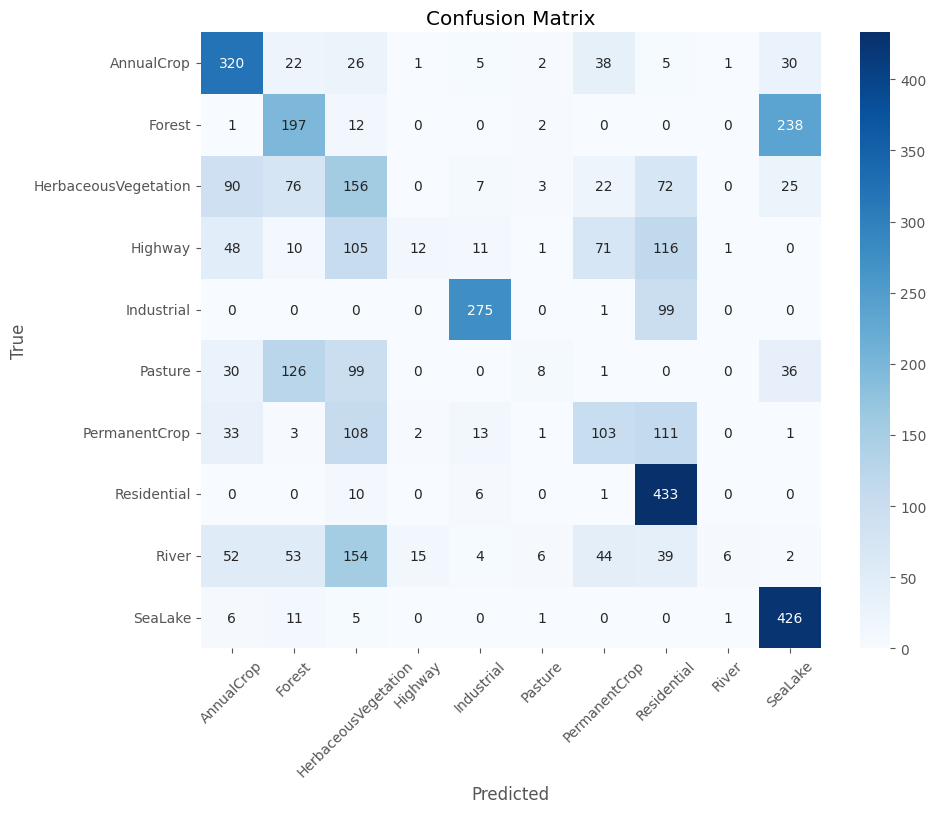


Детальная оценка тестовой выборки:
127/127 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step

Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop       0.55      0.70      0.62       450
              Forest       0.39      0.42      0.40       450
HerbaceousVegetation       0.23      0.36      0.28       450
             Highway       0.36      0.02      0.04       375
          Industrial       0.82      0.77      0.79       375
             Pasture       0.43      0.02      0.04       300
       PermanentCrop       0.36      0.26      0.30       375
         Residential       0.50      0.96      0.66       450
               River       0.50      0.01      0.01       375
             SeaLake       0.56      0.95      0.71       450

            accuracy                           0.48      4050
           macro avg       0.47      0.45      0.39      4050
        weighted avg       0.47      0.48      0.41      4050



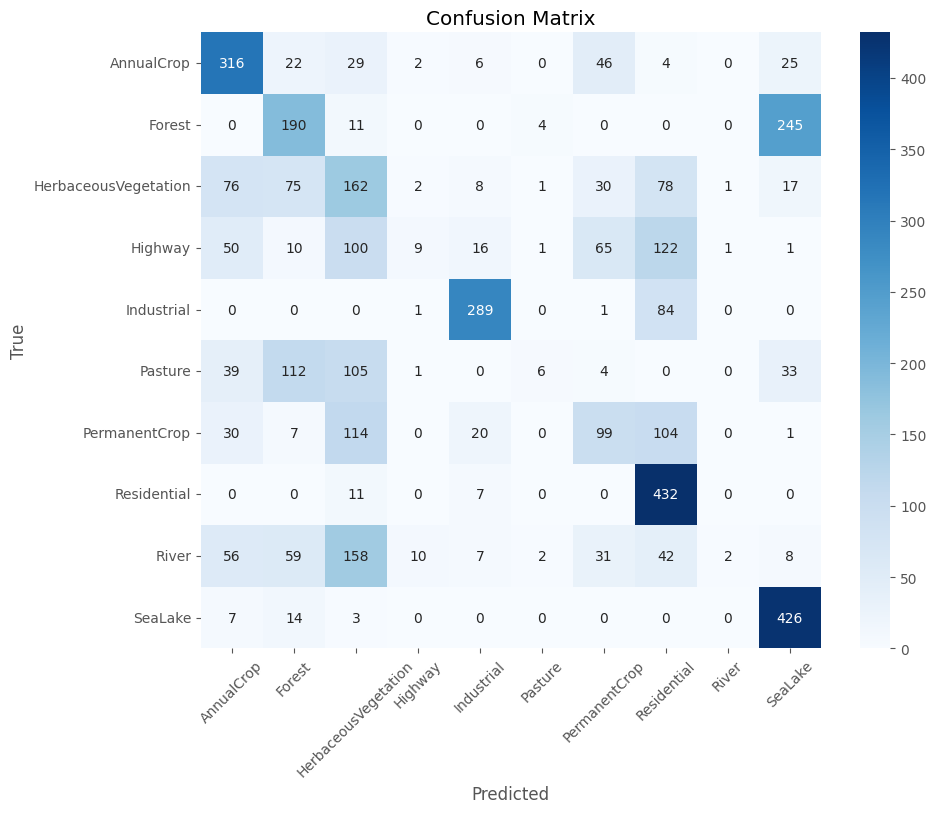


Примеры предсказаний на тестовых данных:
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


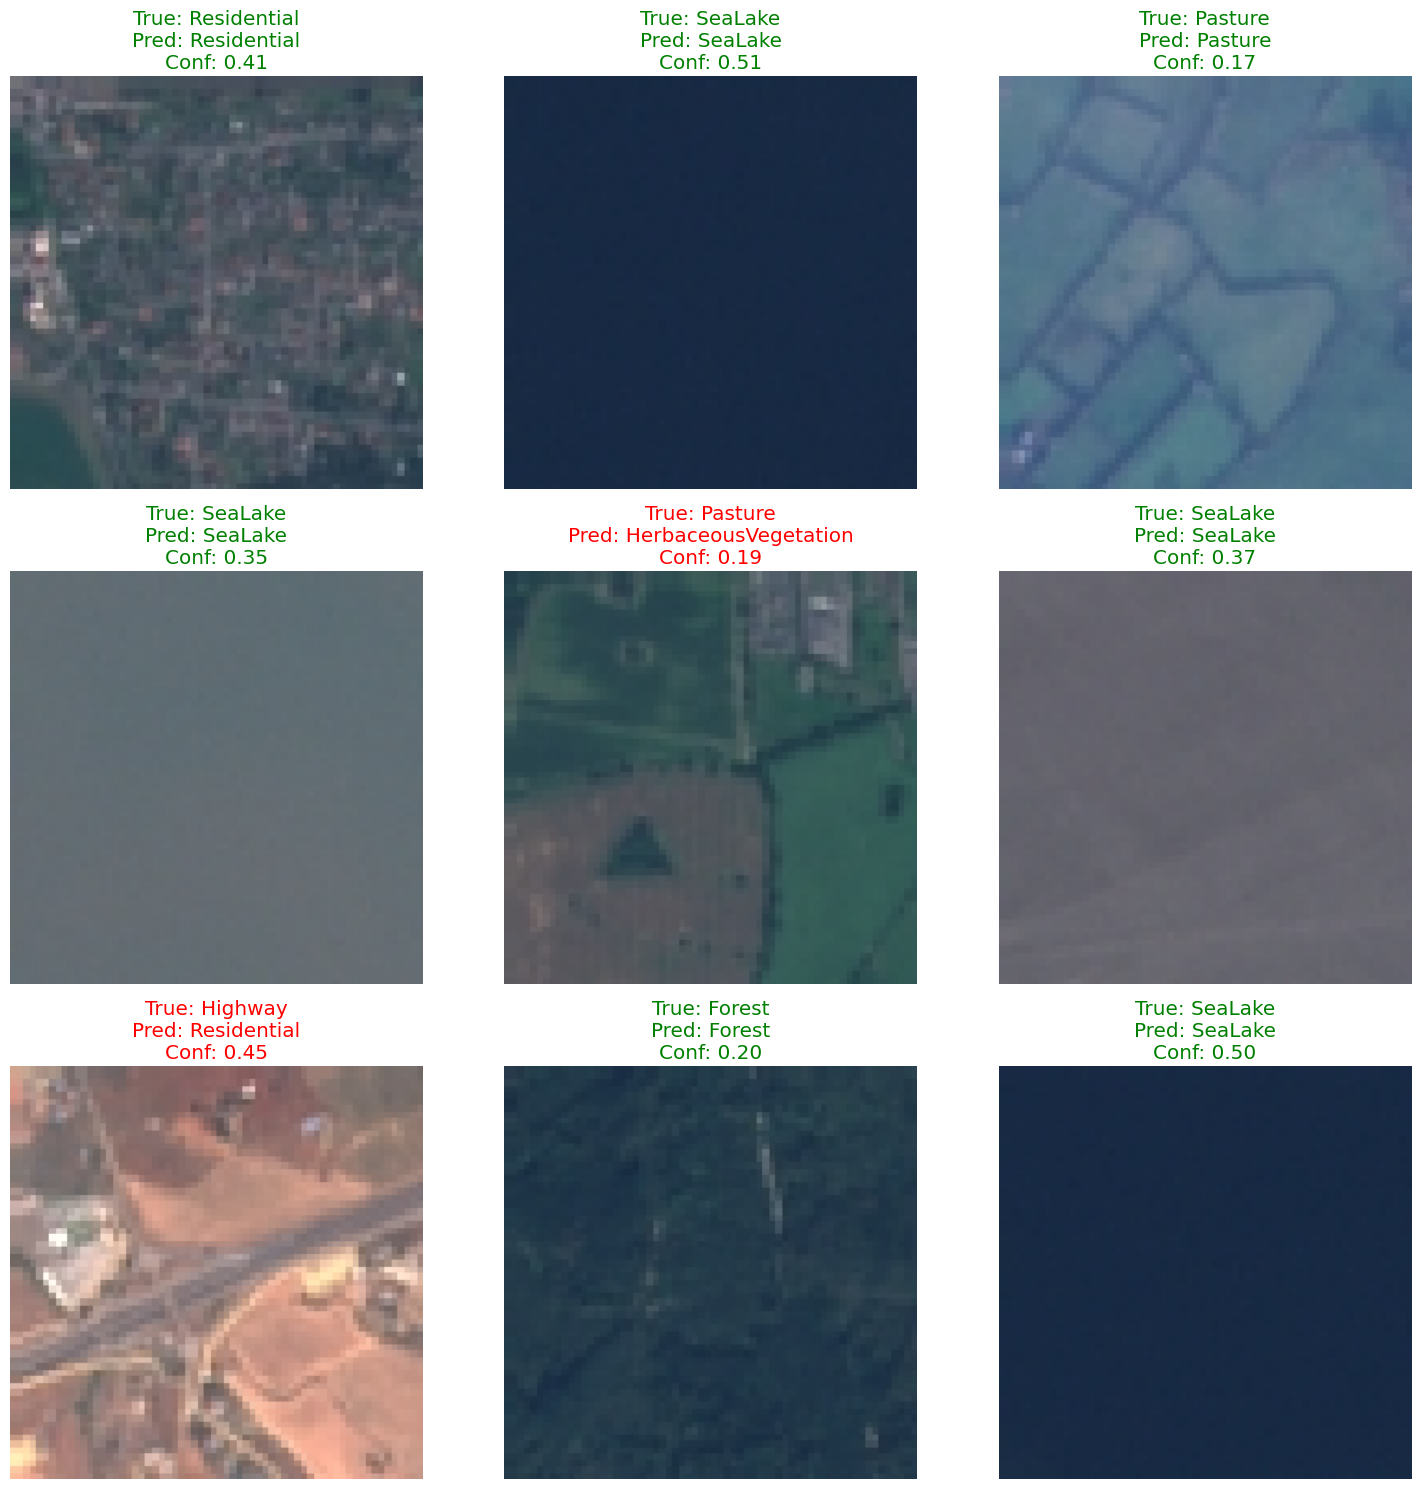

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Подготовка тестового генератора (аналогично валидационному)
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filename',
    y_col='class',
    target_size=(224, 224),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# 2. Оценка на валидационной выборке
print("Оценка на валидационной выборке:")
val_loss, val_acc = model.evaluate(val_generator, verbose=1)
print(f"Validation Accuracy: {val_acc*100:.2f}%")
print(f"Validation Loss: {val_loss:.4f}")

# 3. Оценка на тестовой выборке
print("\nОценка на тестовой выборке:")
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# 4. Подробный отчет по классам
def generate_classification_report(generator):
    # Получаем предсказания
    y_pred = model.predict(generator)
    y_pred_classes = np.argmax(y_pred, axis=1)

    # Истинные метки
    y_true = generator.classes
    class_names = list(generator.class_indices.keys())

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred_classes, target_names=class_names))

    # Confusion matrix
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y_true, y_pred_classes)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()

# Для валидационной выборки
print("\nДетальная оценка валидационной выборки:")
generate_classification_report(val_generator)

# Для тестовой выборки
print("\nДетальная оценка тестовой выборки:")
generate_classification_report(test_generator)

# 5. Визуализация примеров с предсказаниями
def visualize_predictions(generator, num_samples=9):
    plt.figure(figsize=(15, 15))
    samples, labels = next(generator)
    preds = model.predict(samples)

    for i in range(num_samples):
        plt.subplot(3, 3, i+1)
        plt.imshow(samples[i])

        true_class = class_names[np.argmax(labels[i])]
        pred_class = class_names[np.argmax(preds[i])]
        confidence = np.max(preds[i])

        color = 'green' if true_class == pred_class else 'red'
        plt.title(f"True: {true_class}\nPred: {pred_class}\nConf: {confidence:.2f}", color=color)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Визуализируем примеры из тестовой выборки
print("\nПримеры предсказаний на тестовых данных:")
visualize_predictions(test_generator)

### **3.5. Анализ результатов:**
  * Проанализируйте влияние различных параметров на производительность модели, таких как:
      * Количество эпох обучения
      * Размер пакета
      * Функция активации
      * Оптимизатор
      * Регуляризация

-----------------------------------------
**Ваш вывод**
-----------------------------------------


**Количество эпох обучения**:  
Слишком мало эпох → недообучение (низкая точность). Оптимум 20-30 эпох. Слишком много → переобучение (рост ошибки на валидации). Early Stopping помогает автоматически остановить обучение.  

**Размер пакета (batch size)**:  
Меньший размер (16-32) → лучше обобщение, но медленнее обучение. Больший (64-128) → быстрее, но может снизить точность. Оптимум для EuroSat — 32-64.  

**Функция активации**:  
- **ReLU** (лучший выбор для скрытых слоев): быстрая сходимость, избегает затухания градиентов.  
- **Softmax** (обязателен на выходном слое для многоклассовой классификации).  

**Оптимизатор**:  
- **Adam** (лучший баланс): адаптивный LR, хорош по умолчанию.  
- **SGD с моментом** (0.9): может дать лучшие результаты при тонкой настройке, но требует больше эпох.  
- **RMSprop** — альтернатива для задач с шумом.  

**Регуляризация**:  
- **Dropout (0.3-0.5)**: уменьшает переобучение, особенно в плотных слоях.  
- **L2-регуляризация** (λ=1e-4): снижает переобучение весов.  
- **BatchNorm**: стабилизирует обучение, позволяет увеличить LR.  

**Итог**:  
Лучшие параметры для EuroSat:  
- Эпохи: 20-30 (с Early Stopping)  
- Batch size: 32-64  
- Активация: ReLU + Softmax  
- Оптимизатор: Adam (LR=1e-4)  
- Регуляризация: Dropout (0.5) + BatchNorm